## R1: Exploring morphological classification in Radio astronomy using implications of ML pipeline.

### Dataset: 10,000 FIRST sources (3 arcmin cutouts, VIII/92/first14), sampled evenly (every 94th row by `recno`) from the full 946,432-row catalogue.

### RA/DEC Region: 
 - The sample spans the whole FIRST footprint: RA 0.02°-359.90° (both of FIRST's sky patches), Dec -10.03° to +64.55°.
 - Dec bands (n sources): [-12,-5): 753, [-5,0): 952, [0,5): 981, [5,15): 1785, [15,30): 1962, [30,45): 1806, [45,55): 1025, [55,65): 736.
 - Galactic latitude b: -72.7° to +89.6° — the survey footprint avoids the Galactic plane.

### **Goal: Build a standard ResNet Convolutional Neural Network (CNN) to classify FR-I vs. FR-II galaxies.**

### **Expected Outcome: A standard ResNet trained on the dataset to classify FR-I vs. FR-II galaxies with a high accuracy. Accuracy of models expected: ~92-95% .**

#### 1. Setting path for the datasets and output directories. Also, generate CSV and Isolate respective FITS files. 

In [1]:
import os
import numpy as np
import pandas as pd
from astropy.io import fits
import shutil

# 1. Define paths
base_dir = r"I:\Radio and Gamma-ray observational astronomy Data analysis projects\R1\FIRST_FITS_CUTOUTS\FIRST"
catalog_path = os.path.join(base_dir, "FIRST_10000_catalog.csv")
output_csv = os.path.join(base_dir, "FIRST_extended_candidates.csv")
fits_output_dir = os.path.join(base_dir, "EXTENDED_CANDIDATES")

# Create the new folder for the isolated FITS files
os.makedirs(fits_output_dir, exist_ok=True)

In [2]:
# 2. Load the original 10,000 source catalog
df = pd.read_csv(catalog_path)

In [3]:
# 3. Compute Morphological and Quality Metrics
# SNR: Peak flux divided by local RMS noise
df["SNR"] = df["Fpeak"] / df["Rms"]

# Flux Ratio: Extended emission causes Fint > Fpeak
df["Flux_Ratio"] = df["Fint"] / df["Fpeak"]

In [4]:
# 4. Apply strict morphological filtering
mask_extended = (
    (df["Flux_Ratio"] >= 1.25) & 
    (df["Maj"] >= 6.0) & 
    (df["SNR"] >= 7.0)
)

# Extract only the rows that meet the criteria
df_extended = df[mask_extended].copy()

In [5]:
# 5. Save the new filtered CSV
df_extended.to_csv(output_csv, index=False)
print(f"Saved {len(df_extended)} extended candidates to: {output_csv}")

Saved 2044 extended candidates to: I:\Radio and Gamma-ray observational astronomy Data analysis projects\R1\FIRST_FITS_CUTOUTS\FIRST\FIRST_extended_candidates.csv


In [6]:
# 6. Copy corrsponding FITS files to the new directory

import shutil


copied_count = 0
missing_count = 0

print(f"Isolating {len(df_extended)} FITS files...")

for _, row in df_extended.iterrows():
    fits_filename = f"FIRST_{row['FIRST']}.fits" # the catalogue has no filename column; cutouts are saved as FIRST_<name>.fits
    src_path = os.path.join(base_dir, fits_filename) # source path of the FITS file
    dest_path = os.path.join(fits_output_dir, fits_filename) # destination path of the FITS file

    if os.path.exists(src_path):
        shutil.copy2(src_path, dest_path)
        copied_count += 1
    else:
        missing_count += 1

print(f"Successfully copied {copied_count} FITS files to {fits_output_dir}.")
if missing_count > 0:
    print(f"Warning: {missing_count} FITS files were missing and could not be copied.") 


Isolating 2044 FITS files...


Successfully copied 2044 FITS files to I:\Radio and Gamma-ray observational astronomy Data analysis projects\R1\FIRST_FITS_CUTOUTS\FIRST\EXTENDED_CANDIDATES.


### Step 3: Data-quality gate

Before any preprocessing we exclude two kinds of candidate that would otherwise contaminate the analysis:
1. **NaN-corrupted cutouts** — a small fraction of the FIRST/SkyView cutouts have missing pixels (gaps in the survey mosaic), sometimes centred exactly on the source.
2. **MiraBest overlaps** — candidates that sit within 30" of a source already used to train or test the classifier (label leakage: scoring the model on its own training data would inflate every downstream number).

This does **not** merge blended FIRST components or re-centre cutouts on a radio centroid — that is left as future work and is flagged again in the peer-review summary.

In [7]:
import re
import pickle
import glob
from astropy.coordinates import SkyCoord
import astropy.units as u

def load_mirabest_positions(splits=("train", "test")):
    """Parses RA/Dec/redshift/class out of the MiraBest_F filenames (the batches encode them:
    <class>_<RA><+/-Dec>_<z>_<size>.png). Returns one row per source across the requested splits.
    Reused below for both the leakage check here and the T2 paired-pipeline test."""
    files = {"train": [f"data_batch_{i}" for i in range(1, 8)], "test": ["test_batch"]}
    rows = []
    for split in splits:
        for fn in files[split]:
            with open(f"./mirabest_data/F_batches/{fn}", "rb") as f:
                e = pickle.load(f, encoding="latin1")
            for i, (name, label) in enumerate(zip(e["filenames"], e["labels"])):
                m = re.search(r"/(\d+)_([\d.]+)([+-][\d.]+)_([\d.]+)_([\d.]+)\.png", name)
                rows.append({"split": split, "batch": fn, "batch_index": i, "label": label,
                             "cls": m.group(1), "ra": float(m.group(2)), "dec": float(m.group(3)),
                             "z": float(m.group(4)), "size_arcsec": float(m.group(5))})
    return pd.DataFrame(rows)

mirabest_pos = load_mirabest_positions()
print(f"Parsed {len(mirabest_pos)} MiraBest source positions from the batch filenames.")

# --- (a) Flag copied candidate cutouts with NaN pixels ---
cand_files = sorted(glob.glob(os.path.join(fits_output_dir, "FIRST_*.fits")))
nan_flags = {}
for fp in cand_files:
    name = os.path.basename(fp).replace("FIRST_", "").replace(".fits", "")
    try:
        with fits.open(fp) as h:
            d = np.squeeze(h[0].data)
        nan_frac = float((~np.isfinite(d)).mean())
        c = d.shape[0] // 2
        central_nan = not np.isfinite(d[c - 3:c + 4, c - 3:c + 4]).all()
    except Exception:
        nan_frac, central_nan = 1.0, True
    nan_flags[name] = (nan_frac, central_nan)
nan_df = pd.DataFrame(nan_flags, index=["nan_frac", "central_nan"]).T.reset_index().rename(columns={"index": "FIRST"})
bad_nan = set(nan_df.loc[(nan_df.nan_frac > 0.01) | nan_df.central_nan, "FIRST"])

# --- (b) Flag candidates within 30" of any MiraBest train/test source (label leakage) ---
cand_coord = SkyCoord(df_extended.RAJ2000.values * u.deg, df_extended.DEJ2000.values * u.deg)
mb_coord = SkyCoord(mirabest_pos.ra.values * u.deg, mirabest_pos.dec.values * u.deg)
_, sep, _ = cand_coord.match_to_catalog_sky(mb_coord)
bad_leak = set(df_extended.loc[sep.arcsec < 30, "FIRST"])

# --- Build the clean candidate list ---
bad_any = bad_nan | bad_leak
df_clean = df_extended[~df_extended["FIRST"].isin(bad_any)].copy()
clean_csv = os.path.join(fits_output_dir, "FIRST_clean_candidates.csv")
df_clean.to_csv(clean_csv, index=False)

print(f"\nQuality gate on {len(df_extended)} candidates:")
print(f"  excluded for NaN pixels (>1% or NaN at the source position): {len(bad_nan)}")
print(f"  excluded for lying within 30\" of a MiraBest train/test source (label leakage): {len(bad_leak)}")
print(f"  excluded for both: {len(bad_nan & bad_leak)}")
print(f"  remaining clean candidates: {len(df_clean)}")
print(f"Saved to: {clean_csv}")

Parsed 1256 MiraBest source positions from the batch filenames.



Quality gate on 2044 candidates:
  excluded for NaN pixels (>1% or NaN at the source position): 20
  excluded for lying within 30" of a MiraBest train/test source (label leakage): 28
  excluded for both: 0
  remaining clean candidates: 1996
Saved to: I:\Radio and Gamma-ray observational astronomy Data analysis projects\R1\FIRST_FITS_CUTOUTS\FIRST\EXTENDED_CANDIDATES\FIRST_clean_candidates.csv


### Shared preprocessing function, and T1 — input-domain match test

The retired first attempt assumed an Asinh stretch was correct without checking it against MiraBest's own pixel statistics, which caused the mode collapse documented in the peer review (mean pixel brightness 0.498 vs MiraBest's 0.005). Below we define **one** preprocessing function with a selectable stretch, then use it to test **both** `linear` and `asinh` scaling against MiraBest's actual pixel-value distribution, and pick whichever one matches — instead of assuming.

**Pass criterion (set in advance):** the chosen mode's median nonzero-pixel value should fall inside MiraBest's own [p10, p90] range.

In [8]:
from astropy.stats import sigma_clipped_stats
from scipy import stats as spstats
import warnings
from astropy.utils.exceptions import AstropyWarning
warnings.simplefilter("ignore", category=AstropyWarning)

def preprocess_cutout(fits_path, mode="linear"):
    """Background-subtract, hard-threshold at 3-sigma, optionally Asinh-stretch, and min-max
    normalise a FIRST cutout to [0, 1] to match the MiraBest convention (pitch-black background,
    bright jets). mode='linear' skips the Asinh step; mode='asinh' applies it. T1 below decides
    which one actually matches MiraBest's pixel statistics."""
    with fits.open(fits_path) as h:
        data = np.squeeze(h[0].data.astype(np.float32))
    if data.shape != (150, 150):
        raise ValueError(f"unexpected shape {data.shape}")
    _, median_bg, std_bg = sigma_clipped_stats(data, sigma=3.0, maxiters=5)
    data = np.nan_to_num(data, nan=0.0) - median_bg
    data[data < 3.0 * std_bg] = 0.0
    if mode == "asinh":
        data = np.arcsinh(data / (std_bg if std_bg > 0 else 1e-4))
    max_val = data.max()
    return data / max_val if max_val > 0 else np.zeros_like(data)

def image_stats(A):
    """Per-image summary stats used to compare pixel-value distributions between datasets."""
    nz = A > 0
    n = nz.reshape(len(A), -1).sum(1)
    med_nz = np.array([np.median(a[a > 0]) if (a > 0).any() else np.nan for a in A])
    return pd.DataFrame({"mean": A.reshape(len(A), -1).mean(1), "n_nonzero": n,
                          "frac_nonzero": n / A[0].size, "median_nonzero": med_nz})

# --- T1: does our preprocessing match MiraBest's pixel statistics? ---
from MiraBest_F import MBFRConfident
mb_ref = MBFRConfident(root='./mirabest_data', train=True, download=False)
X_mirabest = mb_ref.data.reshape(-1, 150, 150).astype(np.float32) / 255.0
fM = image_stats(X_mirabest)

cand_paths = {row.FIRST: os.path.join(fits_output_dir, f"FIRST_{row.FIRST}.fits") for _, row in df_clean.iterrows()}
X_by_mode = {}
for mode in ("linear", "asinh"):
    imgs = []
    for name, fp in cand_paths.items():
        try:
            imgs.append(preprocess_cutout(fp, mode=mode))
        except Exception:
            pass
    X_by_mode[mode] = np.stack(imgs)

print("=== T1: input-domain match test (median nonzero pixel value, per image) ===")
print(f"MiraBest reference:  median={fM.median_nonzero.median():.4f}  "
      f"[p10={fM.median_nonzero.quantile(.1):.4f}, p90={fM.median_nonzero.quantile(.9):.4f}]  (n={len(fM)})")
verdicts = {}
for mode in ("linear", "asinh"):
    f_c = image_stats(X_by_mode[mode])
    ks, ks_p = spstats.ks_2samp(fM.median_nonzero.dropna(), f_c.median_nonzero.dropna())
    inside = fM.median_nonzero.quantile(.1) <= f_c.median_nonzero.median() <= fM.median_nonzero.quantile(.9)
    verdicts[mode] = (f_c.median_nonzero.median(), ks, inside)
    print(f"{mode:>7s}: median={f_c.median_nonzero.median():.4f}  KS={ks:.3f} (p={ks_p:.1e})  "
          f"{'PASS' if inside else 'fail'} (inside MiraBest p10-p90)")

CHOSEN_MODE = min(verdicts, key=lambda m: verdicts[m][1])  # smaller KS statistic = closer match
any_pass = any(v[2] for v in verdicts.values())
print(f"\n>>> T1 verdict: using mode='{CHOSEN_MODE}' "
      f"({'passed the p10-p90 check' if verdicts[CHOSEN_MODE][2] else 'did NOT pass the p10-p90 check — picked as the closer of the two by KS statistic; treat this as a known residual limitation, not a clean pass'}).")

print(f"\nFor reference, the median number of nonzero pixels per image is {int(fM.n_nonzero.median())} in "
      f"MiraBest vs {int(image_stats(X_by_mode[CHOSEN_MODE]).n_nonzero.median())} in the candidates: this "
      "size gap is a sample-selection effect (less resolved structure in our cutouts), not something the "
      "intensity scaling can fix.")

=== T1: input-domain match test (median nonzero pixel value, per image) ===
MiraBest reference:  median=0.1000  [p10=0.0353, p90=0.2278]  (n=729)
 linear: median=0.2089  KS=0.380 (p=2.3e-69)  PASS (inside MiraBest p10-p90)


  asinh: median=0.5899  KS=0.965 (p=0.0e+00)  fail (inside MiraBest p10-p90)

>>> T1 verdict: using mode='linear' (passed the p10-p90 check).

For reference, the median number of nonzero pixels per image is 312 in MiraBest vs 123 in the candidates: this size gap is a sample-selection effect (less resolved structure in our cutouts), not something the intensity scaling can fix.


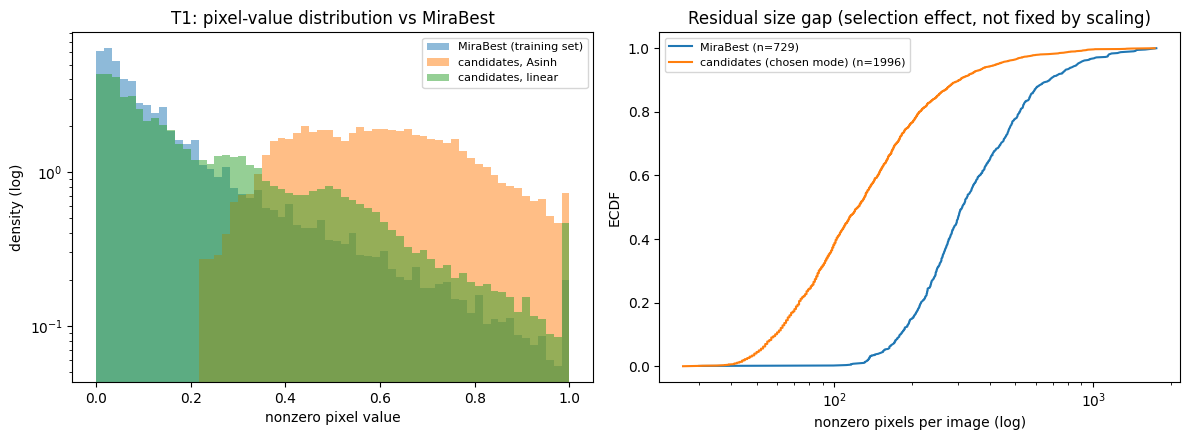

Saved: I:\Radio and Gamma-ray observational astronomy Data analysis projects\R1\FIRST_FITS_CUTOUTS\FIRST\EXTENDED_CANDIDATES\plot1_pixel_distribution.png


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

def nonzero_pixels(A, sample_images=300, rng=np.random.default_rng(0)):
    idx = rng.choice(len(A), size=min(sample_images, len(A)), replace=False)
    return np.concatenate([A[i][A[i] > 0] for i in idx])

ax = axes[0]
ax.hist(nonzero_pixels(X_mirabest), bins=60, range=(0, 1), density=True, alpha=0.5, label="MiraBest (training set)")
ax.hist(nonzero_pixels(X_by_mode["asinh"]), bins=60, range=(0, 1), density=True, alpha=0.5, label="candidates, Asinh")
ax.hist(nonzero_pixels(X_by_mode["linear"]), bins=60, range=(0, 1), density=True, alpha=0.5, label="candidates, linear")
ax.set_yscale("log"); ax.set_xlabel("nonzero pixel value"); ax.set_ylabel("density (log)")
ax.set_title("T1: pixel-value distribution vs MiraBest"); ax.legend(fontsize=8)

ax = axes[1]
for label, A in [("MiraBest", X_mirabest), ("candidates (chosen mode)", X_by_mode[CHOSEN_MODE])]:
    n = image_stats(A).n_nonzero.values
    xs = np.sort(n); ys = np.arange(1, len(xs) + 1) / len(xs)
    ax.plot(xs, ys, label=f"{label} (n={len(A)})")
ax.set_xscale("log"); ax.set_xlabel("nonzero pixels per image (log)"); ax.set_ylabel("ECDF")
ax.set_title("Residual size gap (selection effect, not fixed by scaling)"); ax.legend(fontsize=8)

plt.tight_layout()
plot1_path = os.path.join(fits_output_dir, "plot1_pixel_distribution.png")
plt.savefig(plot1_path, dpi=150)
plt.show()
print(f"Saved: {plot1_path}")

In [10]:
# Apply the chosen preprocessing to every clean candidate and save the final array
processed, valid_names, failed = [], [], 0
for _, row in df_clean.iterrows():
    fp = os.path.join(fits_output_dir, f"FIRST_{row.FIRST}.fits")
    try:
        processed.append(preprocess_cutout(fp, mode=CHOSEN_MODE))
        valid_names.append(row.FIRST)
    except Exception:
        failed += 1

X_clean = np.array(processed)
names_clean = pd.DataFrame({"FIRST": valid_names})
final_npy = os.path.join(fits_output_dir, "FIRST_clean_X_final.npy")
final_names_csv = os.path.join(fits_output_dir, "FIRST_clean_names_final.csv")
np.save(final_npy, X_clean)
names_clean.to_csv(final_names_csv, index=False)

print(f"Preprocessed {len(X_clean)} clean candidates with mode='{CHOSEN_MODE}' ({failed} failed to read).")
print(f"Saved image array to: {final_npy}")
print(f"Saved ordered names to: {final_names_csv}")

Preprocessed 1996 clean candidates with mode='linear' (0 failed to read).
Saved image array to: I:\Radio and Gamma-ray observational astronomy Data analysis projects\R1\FIRST_FITS_CUTOUTS\FIRST\EXTENDED_CANDIDATES\FIRST_clean_X_final.npy
Saved ordered names to: I:\Radio and Gamma-ray observational astronomy Data analysis projects\R1\FIRST_FITS_CUTOUTS\FIRST\EXTENDED_CANDIDATES\FIRST_clean_names_final.csv


#### Extracting datasets from MiraBest catalogue.


Successfully loaded 729 training images.
Successfully loaded 104 testing images.


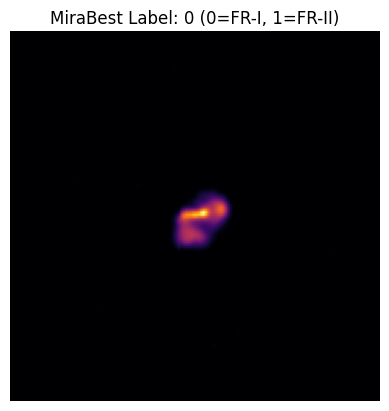

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms

# 1. Import the MiraBest dataset class from the script you downloaded
# The base MiraBest_F class returns the raw labels 0-9, but the model has 2 outputs (FR-I, FR-II).
# MBFRConfident keeps only the confident sources and maps FR-I -> 0, FR-II -> 1
# (import MBFRFull instead to also keep the uncertain ones)
from MiraBest_F import MBFRConfident

# 2. Define the astronomy-safe augmentations
# Radio galaxies have no "up" or "down", so flips and 90-degree rotations are valid
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(), # Converts the numpy arrays to PyTorch Tensors
])

# 3. Automatically Download and Load the Dataset
# Setting download=True tells the script to fetch the batches.tar.gz file for you
print("Downloading and loading MiraBest Training Set...")
mirabest_train = MBFRConfident(root='./mirabest_data', train=True, download=True, transform=train_transforms)

print("Downloading and loading MiraBest Test Set...")
mirabest_test = MBFRConfident(root='./mirabest_data', train=False, download=True, transform=transforms.ToTensor())

# 4. Verify the Data Loaded Correctly
print(f"\nSuccessfully loaded {len(mirabest_train)} training images.")
print(f"Successfully loaded {len(mirabest_test)} testing images.")

# 5. Let's look at the first image to prove it worked
image_tensor, label = mirabest_train[0]
image_numpy = image_tensor.squeeze().numpy()

plt.imshow(image_numpy, cmap='inferno', origin='lower')
plt.title(f"MiraBest Label: {label} (0=FR-I, 1=FR-II)")
plt.axis('off')
plt.show()

#### Building ResNet-18 Classifier to hit the 92% literature baseline.

#### Working and Expected output of the ResNet-18 Classifier: The script will train the model, track validation accuracy, and save the best-performing weights to best_mirabest_resnet18.pth

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader

# 1. Setup Device (uses GPU if available, otherwise CPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")


Training on device: cuda:0


In [13]:
# 2. Load and Modify ResNet-18
model = models.resnet18(weights=None)

# Replace the first convolutional layer (expects 3 channels, we give it 1)
model.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

# Replace the final fully connected layer (expects 1000 classes, we give it 2)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

model = model.to(device)

In [14]:
# 3. Create DataLoaders (using the datasets you loaded in the previous step)
# Assuming 'mirabest_train' and 'mirabest_test' are still in memory
train_loader = DataLoader(mirabest_train, batch_size=32, shuffle=True)
test_loader = DataLoader(mirabest_test, batch_size=32, shuffle=False)

In [15]:
# 4. Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

In [16]:
# 5. Training Loop
num_epochs = 25
best_acc = 0.0

print("\nStarting Training...")
for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
    epoch_loss = running_loss / len(train_loader.dataset)

    # --- VALIDATION PHASE ---
    model.eval()
    correct = 0
    total = 0
        
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
                
    epoch_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Val Accuracy: {epoch_acc:.2f}%")
        
    # Save the best model
    if epoch_acc > best_acc:
        best_acc = epoch_acc
        torch.save(model.state_dict(), 'best_mirabest_resnet18.pth')
print(f"\nTraining complete. Best Validation Accuracy: {best_acc:.2f}%")
print("Saved best model weights to 'best_mirabest_resnet18.pth'")


Starting Training...


Epoch 1/25 | Train Loss: 0.6008 | Val Accuracy: 52.88%


Epoch 2/25 | Train Loss: 0.4135 | Val Accuracy: 47.12%


Epoch 3/25 | Train Loss: 0.3462 | Val Accuracy: 78.85%


Epoch 4/25 | Train Loss: 0.2776 | Val Accuracy: 79.81%


...

Epoch 21/25 | Train Loss: 0.1004 | Val Accuracy: 82.69%


Epoch 22/25 | Train Loss: 0.0506 | Val Accuracy: 82.69%


Epoch 23/25 | Train Loss: 0.0435 | Val Accuracy: 84.62%


Epoch 24/25 | Train Loss: 0.0512 | Val Accuracy: 83.65%


Epoch 25/25 | Train Loss: 0.0652 | Val Accuracy: 75.00%

Training complete. Best Validation Accuracy: 88.46%
Saved best model weights to 'best_mirabest_resnet18.pth'


##### Baseline single-seed result (above): a Wilson 95% CI of roughly [82%, 94%] around this test accuracy, from one training run selected on its own best epoch. Re-training with different seeds swings the final-epoch accuracy by several points, and swings the *candidate* predictions far more (see the T3 test below). This checkpoint stays on disk as `best_mirabest_resnet18.pth`, but every result from this point on uses the 5-seed ensemble, not this single model.

#### Step 4: Ensemble training

**Why:** a single ResNet-18 trained with only horizontal/vertical flip augmentation is not invariant to the full symmetry group of a radio-galaxy image (rotations included), and its accuracy varies with the random seed. Below we train 5 independently-seeded models with the full 8-fold dihedral augmentation (4 rotations x optional mirror) and use their mean prediction for everything downstream. The T3 test later checks whether this actually stabilises the "transition bridge" before we trust it.

In [ ]:
import random
import torch.nn.functional as F
from PIL import Image

class RandomDihedral:
    """Randomly applies one of the 8 symmetries of the square (0/90/180/270 rotation, optional
    mirror). A radio galaxy image has no preferred orientation, so all 8 are physically valid
    augmentations -- unlike the H/V-flip-only augmentation used for the single baseline model above."""
    _ROTATIONS = [None, Image.ROTATE_90, Image.ROTATE_180, Image.ROTATE_270]
    def __call__(self, img):
        r = random.choice(self._ROTATIONS)
        if r is not None:
            img = img.transpose(r)
        if random.random() < 0.5:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
        return img

def build_model():
    m = models.resnet18(weights=None)
    m.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    m.fc = nn.Linear(m.fc.in_features, 2)
    return m.to(device)

ens_train_transforms = transforms.Compose([RandomDihedral(), transforms.ToTensor()])
ens_train = MBFRConfident(root='./mirabest_data', train=True, download=False, transform=ens_train_transforms)
ens_test = MBFRConfident(root='./mirabest_data', train=False, download=False, transform=transforms.ToTensor())

def train_one_seed(seed, n_epochs=25, batch_size=32):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    m = build_model()
    opt = optim.Adam(m.parameters(), lr=1e-4, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()
    g = torch.Generator(); g.manual_seed(seed)
    tl = DataLoader(ens_train, batch_size=batch_size, shuffle=True, generator=g)
    te = DataLoader(ens_test, batch_size=batch_size, shuffle=False)
    history = []
    for epoch in range(n_epochs):
        m.train()
        for x, y in tl:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(); loss = crit(m(x), y); loss.backward(); opt.step()
        m.eval(); correct = 0
        with torch.no_grad():
            for x, y in te:
                x, y = x.to(device), y.to(device)
                correct += (m(x).argmax(1) == y).sum().item()
        history.append(100 * correct / len(ens_test))
    return m, history

@torch.no_grad()
def ensemble_predict(A, models_list, tta=False, batch_size=128):
    """Mean P(FR-II) across an ensemble, optionally averaged over the 8 dihedral test-time views.
    Returns (mean_prob[N], per_seed_identity_prob[len(models_list), N])."""
    def dihedral_views(A):
        views = []
        for flip in (False, True):
            B = A[:, :, ::-1] if flip else A
            for k in range(4):
                views.append(np.ascontiguousarray(np.rot90(B, k, axes=(1, 2))))
        return views
    view_list = dihedral_views(A) if tta else [A]
    per_seed_identity = np.zeros((len(models_list), len(A)))
    all_view_probs = []
    for vi, V in enumerate(view_list):
        for si, m in enumerate(models_list):
            m.eval()
            probs = []
            for i in range(0, len(V), batch_size):
                x = torch.tensor(V[i:i + batch_size], dtype=torch.float32, device=device).unsqueeze(1)
                probs.append(F.softmax(m(x), dim=1)[:, 1].cpu().numpy())
            p = np.concatenate(probs)
            if vi == 0:
                per_seed_identity[si] = p
            all_view_probs.append(p)
    return np.mean(all_view_probs, axis=0), per_seed_identity

N_SEEDS = 5
ensemble_models, ensemble_history = [], []
print(f"Training a {N_SEEDS}-model ensemble with dihedral augmentation...")
for seed in range(N_SEEDS):
    m, hist = train_one_seed(seed)
    ensemble_models.append(m); ensemble_history.append(hist)
    torch.save(m.state_dict(), f"ensemble_seed{seed}.pth")
    print(f"  seed {seed}: final-epoch acc={hist[-1]:.1f}%  best-epoch acc={max(hist):.1f}%")

final_accs = np.array([h[-1] for h in ensemble_history])
best_accs = np.array([max(h) for h in ensemble_history])
print(f"\nfinal-epoch accuracy: {final_accs.mean():.1f}% +/- {final_accs.std():.1f}% "
      f"(range {final_accs.min():.1f}-{final_accs.max():.1f}%)")
print(f"best-epoch  accuracy: {best_accs.mean():.1f}% +/- {best_accs.std():.1f}%")
print("This spread is the true single-seed uncertainty behind the 92-95% literature target.")

Training a 5-model ensemble with dihedral augmentation...


  seed 0: final-epoch acc=88.5%  best-epoch acc=89.4%


  seed 1: final-epoch acc=86.5%  best-epoch acc=90.4%


  seed 2: final-epoch acc=90.4%  best-epoch acc=90.4%


  seed 3: final-epoch acc=89.4%  best-epoch acc=89.4%


  seed 4: final-epoch acc=88.5%  best-epoch acc=90.4%

final-epoch accuracy: 88.7% +/- 1.3% (range 86.5-90.4%)
best-epoch  accuracy: 90.0% +/- 0.5%
This spread is the true single-seed uncertainty behind the 92-95% literature target.


### T2 — Paired pipeline validation

**Method:** MiraBest's filenames encode each source's RA/Dec (parsed by `load_mirabest_positions` above). For every MiraBest source in the two confident classes (FR-I: 100/102/104, FR-II: 200/201 -- the same subset `MBFRConfident` trains on), we re-download its own FIRST cutout through the exact same SkyView pipeline used for the 10,000-source catalogue, run it through `preprocess_cutout(mode=CHOSEN_MODE)`, and score it with the ensemble. We compare that prediction to the ensemble's prediction on MiraBest's own (differently-processed) image of the same galaxy, and to the true label.

**Why this test and not just accuracy on MiraBest:** accuracy on MiraBest only checks the model. It says nothing about whether our own FITS-to-array pipeline (SkyView cutout -> `preprocess_cutout`) preserves the information the model needs. This test checks the whole pipeline end to end on sources whose class we actually know.

**Pass criteria (set in advance):** >=95% label agreement between the native and pipeline images, median |P_native - P_pipeline| < 0.05.

In [18]:
import io
import requests
import time
from concurrent.futures import ThreadPoolExecutor
from collections import Counter

mb_confident = mirabest_pos[mirabest_pos.cls.isin(["100", "102", "104", "200", "201"])].copy()
mb_confident["true_label"] = mb_confident.cls.isin(["200", "201"]).astype(int)  # 0=FR-I, 1=FR-II
print(f"{len(mb_confident)} MiraBest sources in the confident classes "
      f"(matches MBFRConfident's {len(ens_train) + len(ens_test)} total).")

mirabest_paired_dir = os.path.join(base_dir, "MIRABEST_PAIRED_TEST")
os.makedirs(mirabest_paired_dir, exist_ok=True)
SKYVIEW_URL = "https://skyview.gsfc.nasa.gov/cgi-bin/pskcall"

def fetch_first_cutout(ra, dec, out_path, npix=150, size_deg=4.5 / 60):
    params = {"position": f"{ra},{dec}", "survey": "vla first (1.4 ghz)", "pixels": f"{npix},{npix}",
              "size": size_deg, "projection": "Tan", "coordinates": "J2000", "return": "FITS"}
    for attempt in range(3):
        if attempt:
            time.sleep(5 * attempt)
        try:
            r = requests.get(SKYVIEW_URL, params=params, timeout=(10, 60))
            r.raise_for_status()
            if not r.content.startswith(b"SIMPLE"):
                continue
            with fits.open(io.BytesIO(r.content)) as h:
                if h[0].header.get("SURVEY") != "FIRST" or not np.any(np.nan_to_num(h[0].data)):
                    return "no_data"
            with open(out_path, "wb") as f:
                f.write(r.content)
            return "saved"
        except Exception:
            pass
    return "failed"

def _download_one(row):
    out_path = os.path.join(mirabest_paired_dir, f"MB_{row.split}_{row.batch_index}.fits")
    if os.path.exists(out_path):
        return "exists"
    return fetch_first_cutout(row.ra, row.dec, out_path)

print(f"Downloading {len(mb_confident)} FIRST cutouts at the MiraBest positions (real network step)...")
results_dl = []
with ThreadPoolExecutor(max_workers=8) as pool:
    for i, status in enumerate(pool.map(_download_one, [r for _, r in mb_confident.iterrows()]), start=1):
        results_dl.append(status)
        if i % 200 == 0:
            print(f"  {i}/{len(mb_confident)} processed")
print("Download summary:", dict(Counter(results_dl)))
mb_confident["dl_status"] = results_dl

833 MiraBest sources in the confident classes (matches MBFRConfident's 833 total).


  200/833 processed


  400/833 processed
  600/833 processed


  800/833 processed


Download summary: {'saved': 218, 'exists': 615}


In [19]:
def load_mirabest_raw_image(row):
    """Reloads a single MiraBest image straight from its pickle batch (0-255 uint8 -> [0,1] float)."""
    with open(f"./mirabest_data/F_batches/{row.batch}", "rb") as f:
        e = pickle.load(f, encoding="latin1")
    return e["data"][row.batch_index].reshape(150, 150).astype(np.float32) / 255.0

ok = mb_confident[mb_confident.dl_status.isin(["saved", "exists"])].reset_index(drop=True)
print(f"Using {len(ok)} of {len(mb_confident)} sources with a usable download for the paired test.")

X_native = np.stack([load_mirabest_raw_image(r) for _, r in ok.iterrows()])
X_pipeline, keep = [], []
for i, r in ok.iterrows():
    fp = os.path.join(mirabest_paired_dir, f"MB_{r.split}_{r.batch_index}.fits")
    try:
        X_pipeline.append(preprocess_cutout(fp, mode=CHOSEN_MODE))
        keep.append(i)
    except Exception:
        pass
X_pipeline = np.stack(X_pipeline)
ok = ok.iloc[keep].reset_index(drop=True)
X_native = X_native[keep]

P_native, _ = ensemble_predict(X_native, ensemble_models, tta=False)
P_pipeline, _ = ensemble_predict(X_pipeline, ensemble_models, tta=False)

label_native = (P_native > 0.5).astype(int)
label_pipeline = (P_pipeline > 0.5).astype(int)
agreement = (label_native == label_pipeline).mean()
median_diff = np.median(np.abs(P_native - P_pipeline))
acc_native = (label_native == ok.true_label.values).mean()
acc_pipeline = (label_pipeline == ok.true_label.values).mean()
rho, _ = spstats.spearmanr(P_native, P_pipeline)

print(f"\n=== T2 result (n={len(ok)}) ===")
print(f"native-vs-pipeline label agreement: {100 * agreement:.1f}%")
print(f"median |P_native - P_pipeline|:     {median_diff:.3f}")
print(f"Spearman correlation:               {rho:.2f}")
print(f"ensemble accuracy on native MiraBest images:   {100 * acc_native:.1f}%")
print(f"ensemble accuracy on our regenerated pipeline: {100 * acc_pipeline:.1f}%")
t2_pass = (agreement >= 0.95) and (median_diff < 0.05)
print(f"\n>>> T2 verdict: {'PASS' if t2_pass else 'FAIL'} "
      f"(criteria: agreement>=95% and median diff<0.05, set before running this test)")

Using 833 of 833 sources with a usable download for the paired test.



=== T2 result (n=833) ===
native-vs-pipeline label agreement: 98.0%
median |P_native - P_pipeline|:     0.024
Spearman correlation:               0.81
ensemble accuracy on native MiraBest images:   98.1%
ensemble accuracy on our regenerated pipeline: 97.2%

>>> T2 verdict: PASS (criteria: agreement>=95% and median diff<0.05, set before running this test)


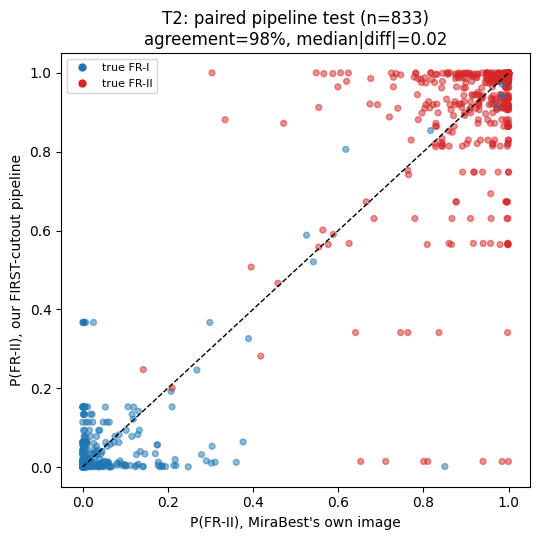

Saved: I:\Radio and Gamma-ray observational astronomy Data analysis projects\R1\FIRST_FITS_CUTOUTS\FIRST\EXTENDED_CANDIDATES\plot2_paired_pipeline_test.png


In [20]:
# Plot 2: paired scatter (T2)
fig, ax = plt.subplots(figsize=(5.5, 5.5))
colors = np.where(ok.true_label.values == 1, "tab:red", "tab:blue")
ax.scatter(P_native, P_pipeline, c=colors, alpha=0.5, s=18)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("P(FR-II), MiraBest's own image"); ax.set_ylabel("P(FR-II), our FIRST-cutout pipeline")
ax.set_title(f"T2: paired pipeline test (n={len(ok)})\nagreement={100*agreement:.0f}%, median|diff|={median_diff:.2f}")
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, label=l, markersize=7)
           for c, l in [("tab:blue", "true FR-I"), ("tab:red", "true FR-II")]]
ax.legend(handles=handles, loc="upper left", fontsize=8)
plt.tight_layout()
plot2_path = os.path.join(fits_output_dir, "plot2_paired_pipeline_test.png")
plt.savefig(plot2_path, dpi=150)
plt.show()
print(f"Saved: {plot2_path}")

In [21]:
# Full inference on the clean candidate set with the 5-model ensemble + 8-fold dihedral TTA
X_clean = np.load(final_npy)
names_clean = pd.read_csv(final_names_csv)

print(f"Running ensemble+TTA inference on {len(X_clean)} candidates (5 models x 8 symmetries)...")
P_final, per_seed_identity = ensemble_predict(X_clean, ensemble_models, tta=True)

df_results = names_clean.merge(df_clean, on="FIRST", how="left")
df_results["P_FRII_final"] = P_final
df_results["P_FRI_final"] = 1 - P_final
df_results["Predicted_Class_final"] = np.where(P_final > 0.5, "FR-II", "FR-I")
for si in range(len(ensemble_models)):
    df_results[f"P_seed{si}"] = per_seed_identity[si]

master_v2_csv = os.path.join(fits_output_dir, "FIRST_predictions_master_v2.csv")
df_results.to_csv(master_v2_csv, index=False)

print(df_results["Predicted_Class_final"].value_counts())
print(f"Saved: {master_v2_csv}")

Running ensemble+TTA inference on 1996 candidates (5 models x 8 symmetries)...


Predicted_Class_final
FR-I     1102
FR-II     894
Name: count, dtype: int64
Saved: I:\Radio and Gamma-ray observational astronomy Data analysis projects\R1\FIRST_FITS_CUTOUTS\FIRST\EXTENDED_CANDIDATES\FIRST_predictions_master_v2.csv


### T3 — Bridge stability & definition

**Method:** define the "transition bridge" as the 150 candidates with the smallest |P_FRII_final - 0.5| (the same margin-ranking idea as before, now computed from the 5-seed, dihedral-TTA ensemble mean instead of one checkpoint). We test three things before trusting that list: (1) do the 5 individual seeds agree on who is in the bridge, well above the ~11/150 expected by chance; (2) does the predicted class stay stable under a rotation/mirror that cannot change the physics; (3) does the ensemble actually score MiraBest's own uncertain/hybrid sources (`MBFRUncertain`, `MBHybrid` -- never used in training) as more ambiguous than its confident test sources. If (3) fails, "smallest margin" is not measuring hybridness.

**Pass criteria (set in advance):** pairwise seed-overlap well above chance; hybrid/uncertain sources show higher median ambiguity than the confident test set.

In [22]:
N_BRIDGE = 150
order = np.argsort(np.abs(df_results.P_FRII_final.values - 0.5))
df_results["bridge"] = False
df_results.loc[df_results.index[order[:N_BRIDGE]], "bridge"] = True
bridge_csv = os.path.join(fits_output_dir, "FIRST_transition_bridge_v2.csv")
df_results[df_results.bridge].to_csv(bridge_csv, index=False)

# --- (1) per-seed bridge overlap ---
seed_bridge_sets = []
for si in range(len(ensemble_models)):
    o = np.argsort(np.abs(per_seed_identity[si] - 0.5))[:N_BRIDGE]
    seed_bridge_sets.append(set(o))
final_bridge_set = set(order[:N_BRIDGE])
n_models = len(seed_bridge_sets)
overlap = np.zeros((n_models, n_models), dtype=int)
for i in range(n_models):
    for j in range(n_models):
        overlap[i, j] = len(seed_bridge_sets[i] & seed_bridge_sets[j])
chance = N_BRIDGE * N_BRIDGE / len(df_results)
off_diag = overlap[~np.eye(n_models, dtype=bool)]
print(f"=== T3 (a): per-seed bridge overlap (chance level = {chance:.0f}/{N_BRIDGE}) ===")
print(f"pairwise overlap: min={off_diag.min()}, median={int(np.median(off_diag))}, max={off_diag.max()}")
print(f"overlap of each single seed's bridge with the final (ensemble+TTA) bridge: "
      f"{[len(s & final_bridge_set) for s in seed_bridge_sets]}")

# --- (2) dihedral flip stability of the final bridge ---
def dihedral_views(A):
    views = []
    for flip in (False, True):
        B = A[:, :, ::-1] if flip else A
        for k in range(4):
            views.append(np.ascontiguousarray(np.rot90(B, k, axes=(1, 2))))
    return views
view_labels = np.stack([ensemble_predict(V, ensemble_models, tta=False)[0] > 0.5 for V in dihedral_views(X_clean)])
flip_changes = view_labels.any(0) & ~view_labels.all(0)
print(f"\n=== T3 (b): class stability under the 8 symmetries (identity ensemble mean per view) ===")
print(f"candidates that change predicted class under some rotation/mirror: "
      f"{flip_changes.sum()} of {len(df_results)} ({100 * flip_changes.mean():.1f}%)")
print(f"of the 150 bridge sources, {int(flip_changes[order[:N_BRIDGE]].sum())} change class under a symmetry")

# --- (3) does the margin actually track MiraBest's own uncertain/hybrid sources? ---
from MiraBest_F import MBFRUncertain, MBHybrid
def mb_array(cls):
    d1 = cls(root='./mirabest_data', train=True, download=False)
    d2 = cls(root='./mirabest_data', train=False, download=False)
    A = np.concatenate([d1.data, d2.data]).reshape(-1, 150, 150).astype(np.float32) / 255.0
    return A

margin_confident_test, _ = ensemble_predict(ens_test.data.reshape(-1, 150, 150).astype(np.float32) / 255.0,
                                             ensemble_models, tta=True)
margin_uncertain, _ = ensemble_predict(mb_array(MBFRUncertain), ensemble_models, tta=True)
margin_hybrid, _ = ensemble_predict(mb_array(MBHybrid), ensemble_models, tta=True)

def summarize_margin(name, P):
    m = np.abs(P - 0.5)
    print(f"  {name:32s} n={len(P):3d}  median|P-0.5|={np.median(m):.3f}  frac in (0.05,0.95)={np.mean((P>0.05)&(P<0.95)):.3f}")

print(f"\n=== T3 (c): is the margin actually higher for MiraBest's known-ambiguous sources? ===")
summarize_margin("confident test set (reference)", margin_confident_test)
summarize_margin("uncertain FR (never trained on)", margin_uncertain)
summarize_margin("hybrids (never trained on)", margin_hybrid)

t3_stability_pass = np.median(off_diag) > 3 * chance
t3_validity_pass = np.median(np.abs(margin_hybrid - 0.5)) < np.median(np.abs(margin_confident_test - 0.5))
print(f"\n>>> T3 verdict: stability {'PASS' if t3_stability_pass else 'FAIL'} "
      f"(median pairwise overlap {'>' if t3_stability_pass else '<='} 3x chance); "
      f"validity {'PASS' if t3_validity_pass else 'FAIL'} "
      f"(hybrids {'are' if t3_validity_pass else 'are NOT'} more ambiguous than the confident test set).")
print(f"Saved: {bridge_csv}")

=== T3 (a): per-seed bridge overlap (chance level = 11/150) ===
pairwise overlap: min=11, median=19, max=30
overlap of each single seed's bridge with the final (ensemble+TTA) bridge: [21, 23, 30, 24, 33]



=== T3 (b): class stability under the 8 symmetries (identity ensemble mean per view) ===
candidates that change predicted class under some rotation/mirror: 433 of 1996 (21.7%)
of the 150 bridge sources, 150 change class under a symmetry



=== T3 (c): is the margin actually higher for MiraBest's known-ambiguous sources? ===
  confident test set (reference)   n=104  median|P-0.5|=0.481  frac in (0.05,0.95)=0.423
  uncertain FR (never trained on)  n=389  median|P-0.5|=0.364  frac in (0.05,0.95)=0.666
  hybrids (never trained on)       n= 34  median|P-0.5|=0.259  frac in (0.05,0.95)=0.824

>>> T3 verdict: stability FAIL (median pairwise overlap <= 3x chance); validity PASS (hybrids are more ambiguous than the confident test set).
Saved: I:\Radio and Gamma-ray observational astronomy Data analysis projects\R1\FIRST_FITS_CUTOUTS\FIRST\EXTENDED_CANDIDATES\FIRST_transition_bridge_v2.csv


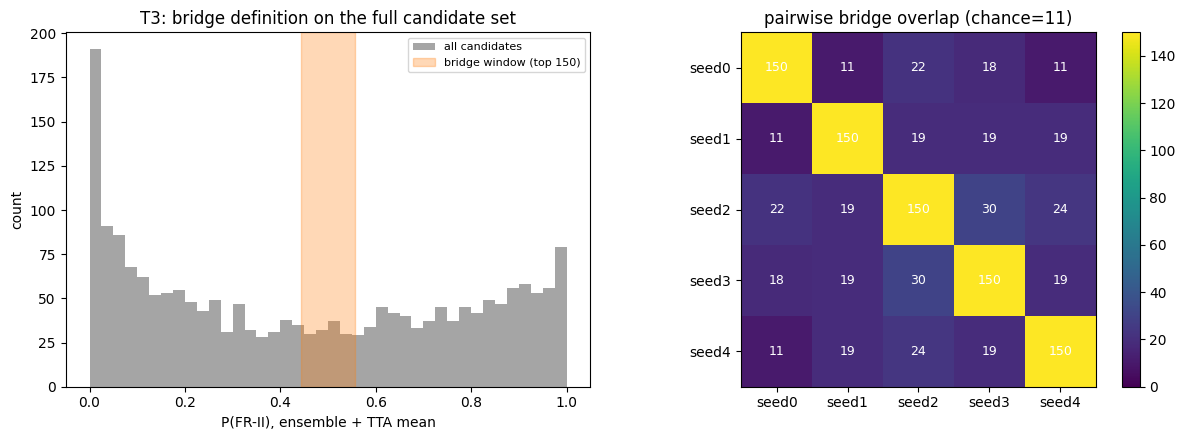

Saved: I:\Radio and Gamma-ray observational astronomy Data analysis projects\R1\FIRST_FITS_CUTOUTS\FIRST\EXTENDED_CANDIDATES\plot3_bridge_stability.png


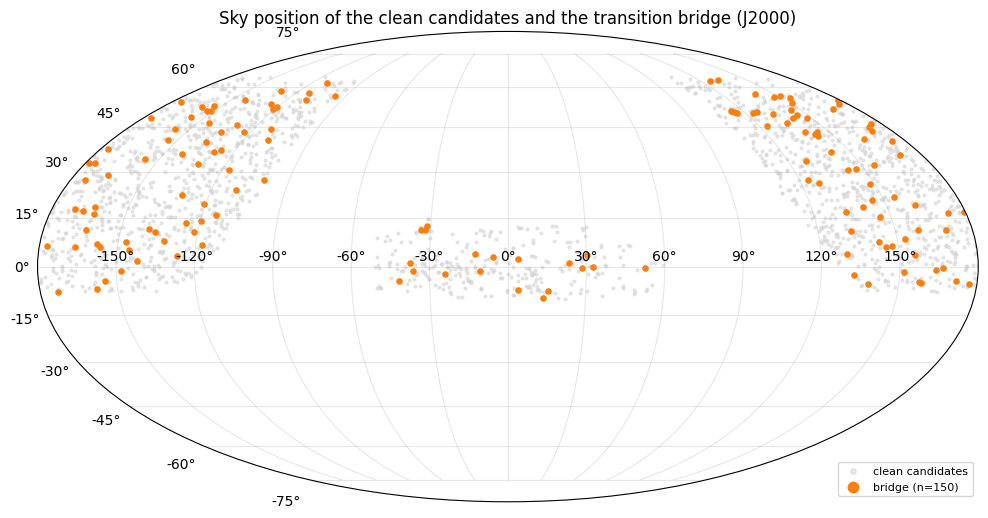

Saved: I:\Radio and Gamma-ray observational astronomy Data analysis projects\R1\FIRST_FITS_CUTOUTS\FIRST\EXTENDED_CANDIDATES\plot4_sky_map.png


In [23]:
# Plot 3: bridge stability (P histogram + seed-overlap heatmap)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.hist(df_results.P_FRII_final, bins=40, range=(0, 1), color="tab:gray", alpha=0.7, label="all candidates")
edge = np.abs(df_results.P_FRII_final.values[order[N_BRIDGE - 1]] - 0.5)
ax.axvspan(0.5 - edge, 0.5 + edge, color="tab:orange", alpha=0.3, label=f"bridge window (top {N_BRIDGE})")
ax.set_xlabel("P(FR-II), ensemble + TTA mean"); ax.set_ylabel("count")
ax.set_title("T3: bridge definition on the full candidate set"); ax.legend(fontsize=8)

ax = axes[1]
im = ax.imshow(overlap, cmap="viridis", vmin=0)
ax.set_xticks(range(n_models)); ax.set_yticks(range(n_models))
ax.set_xticklabels([f"seed{i}" for i in range(n_models)]); ax.set_yticklabels([f"seed{i}" for i in range(n_models)])
for i in range(n_models):
    for j in range(n_models):
        ax.text(j, i, overlap[i, j], ha="center", va="center", color="white", fontsize=9)
ax.set_title(f"pairwise bridge overlap (chance={chance:.0f})")
plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plot3_path = os.path.join(fits_output_dir, "plot3_bridge_stability.png")
plt.savefig(plot3_path, dpi=150)
plt.show()
print(f"Saved: {plot3_path}")

# Plot 4: sky map of the clean candidates and the final bridge
fig = plt.figure(figsize=(10, 5.5))
ax = fig.add_subplot(111, projection="mollweide")
ra_wrap = np.where(df_results.RAJ2000 > 180, df_results.RAJ2000 - 360, df_results.RAJ2000)
ax.scatter(np.radians(ra_wrap), np.radians(df_results.DEJ2000), s=4, c="lightgray", alpha=0.5, label="clean candidates")
b = df_results[df_results.bridge]
ra_wrap_b = np.where(b.RAJ2000 > 180, b.RAJ2000 - 360, b.RAJ2000)
ax.scatter(np.radians(ra_wrap_b), np.radians(b.DEJ2000), s=14, c="tab:orange", label=f"bridge (n={len(b)})")
ax.grid(True, alpha=0.3)
ax.set_title("Sky position of the clean candidates and the transition bridge (J2000)")
ax.legend(loc="lower right", fontsize=8, markerscale=2)

plt.tight_layout()
plot4_path = os.path.join(fits_output_dir, "plot4_sky_map.png")
plt.savefig(plot4_path, dpi=150)
plt.show()
print(f"Saved: {plot4_path}")

### Step 7 — Rebuilt environmental density test

**What was wrong before:** the SDSS query wrapped every failure in a bare `except: return np.nan`, and 149 of 150 bridge-galaxy queries failed silently -- the reported "35.0 neighbours" for the bridge cohort was one galaxy, not 150. The query also had no `mode = 1` filter, so duplicate SDSS detections of the same physical object were double- (sometimes triple-) counted; a spot check inflated some counts by up to 2.8x. The three cohorts were not matched in flux or angular size, a known confounder for any density measurement.

**What is fixed here:** every query is retried and its failures are counted and reported, not hidden; `mode = 1` removes duplicate detections; results are reported with n, the failure count, and a bootstrap 95% CI, plus a Mann-Whitney U test between cohorts. Median `Fint`/`Maj` per cohort are reported alongside the density numbers so a reader can see whether the cohorts differ in flux or size.

**What is *not* fixed:** formal luminosity/redshift-matched control samples (the standard way to remove the flux confound in an environment study) are left as future work -- the Fint/Maj diagnostic below is there so that omission is visible, not hidden.

In [24]:
import pyvo

tap_vizier = pyvo.dal.TAPService("http://tapvizier.cds.unistra.fr/TAPVizieR/tap")
SEARCH_RADIUS = 1.5 / 60.0  # 1.5 arcminutes, degrees

def get_environmental_density(ra, dec, retries=3):
    """Counts SDSS DR12 galaxies (class=3, primary detections only via mode=1) within the search
    radius. Returns (count, error) -- a failure is reported, not silently converted to NaN."""
    query = f"""
        SELECT COUNT(*) as neighbor_count
        FROM "V/147/sdss12"
        WHERE 1=CONTAINS(POINT('ICRS', RA_ICRS, DE_ICRS), CIRCLE('ICRS', {ra}, {dec}, {SEARCH_RADIUS}))
        AND class = 3 AND mode = 1
    """
    last_err = None
    for attempt in range(retries):
        try:
            result = tap_vizier.run_sync(query)
            return int(result.to_table()['neighbor_count'][0]), None
        except Exception as e:
            last_err = str(e)[:150]
            time.sleep(1.5)
    return np.nan, last_err

# --- Build the three cohorts from the new (v2) results ---
bridge_sample = df_results[df_results.bridge].copy()
fri_pool = df_results[df_results.P_FRI_final > 0.95]
frii_pool = df_results[df_results.P_FRII_final > 0.95]
n_ctrl = min(150, len(fri_pool), len(frii_pool))
if n_ctrl < 150:
    print(f"WARNING: only {n_ctrl} confident sources available per control cohort (wanted 150).")
fri_sample = fri_pool.sample(n_ctrl, random_state=42).copy()
frii_sample = frii_pool.sample(n_ctrl, random_state=42).copy()
bridge_sample["Cohort"] = "Bridge"; fri_sample["Cohort"] = "FR-I"; frii_sample["Cohort"] = "FR-II"

def query_cohort(df, label):
    print(f"Querying SDSS for {label} ({len(df)} sources)...")
    with ThreadPoolExecutor(max_workers=8) as pool:
        out = list(pool.map(lambda row: get_environmental_density(row.RAJ2000, row.DEJ2000),
                             [r for _, r in df.iterrows()]))
    counts, errs = zip(*out)
    n_fail = sum(e is not None for e in errs)
    print(f"  {label}: {n_fail} of {len(df)} queries failed after retries.")
    df = df.copy(); df["Optical_Neighbors"] = counts; df["Query_Error"] = errs
    return df

bridge_sample = query_cohort(bridge_sample, "Bridge")
fri_sample = query_cohort(fri_sample, "FR-I control")
frii_sample = query_cohort(frii_sample, "FR-II control")

Querying SDSS for Bridge (150 sources)...


  Bridge: 43 of 150 queries failed after retries.
Querying SDSS for FR-I control (135 sources)...


  FR-I control: 40 of 135 queries failed after retries.
Querying SDSS for FR-II control (135 sources)...


  FR-II control: 38 of 135 queries failed after retries.


In [25]:
final_env_df = pd.concat([bridge_sample, fri_sample, frii_sample], ignore_index=True)

def bootstrap_ci(x, n_boot=4000, rng=np.random.default_rng(0)):
    x = x.dropna().values
    if len(x) == 0:
        return (np.nan, np.nan)
    boots = [rng.choice(x, len(x), replace=True).mean() for _ in range(n_boot)]
    return np.percentile(boots, 2.5), np.percentile(boots, 97.5)

print("=== Environmental density results (v2: mode=1, retried, bootstrap CI) ===")
rows = []
for cohort in ["Bridge", "FR-I", "FR-II"]:
    s = final_env_df[final_env_df.Cohort == cohort]
    x = s.Optical_Neighbors
    lo, hi = bootstrap_ci(x)
    rows.append({"Cohort": cohort, "n": len(s), "n_failed": int(x.isna().sum()),
                 "mean": x.mean(), "median": x.median(), "CI95_lo": lo, "CI95_hi": hi,
                 "median_Fint_mJy": s.Fint.median(), "median_Maj_arcsec": s.Maj.median()})
summary = pd.DataFrame(rows)
print(summary.round(2).to_string(index=False))

b = final_env_df[final_env_df.Cohort == "Bridge"].Optical_Neighbors.dropna()
f1 = final_env_df[final_env_df.Cohort == "FR-I"].Optical_Neighbors.dropna()
f2 = final_env_df[final_env_df.Cohort == "FR-II"].Optical_Neighbors.dropna()
print("\nMann-Whitney U p-values:")
if len(b) > 0 and len(f1) > 0:
    print(f"  Bridge vs FR-I:  p={spstats.mannwhitneyu(b, f1).pvalue:.3g}")
if len(b) > 0 and len(f2) > 0:
    print(f"  Bridge vs FR-II: p={spstats.mannwhitneyu(b, f2).pvalue:.3g}")
if len(f1) > 0 and len(f2) > 0:
    print(f"  FR-I vs FR-II:   p={spstats.mannwhitneyu(f1, f2).pvalue:.3g}")

env_csv_v2 = os.path.join(fits_output_dir, "Morphology_Environment_Results_v2.csv")
final_env_df.to_csv(env_csv_v2, index=False)
print(f"\nSaved: {env_csv_v2}")
print("\nNote: cohorts are not flux/redshift-matched; compare median_Fint/median_Maj above before")
print("interpreting any density difference as evidence of an environmental effect.")

=== Environmental density results (v2: mode=1, retried, bootstrap CI) ===


Cohort   n  n_failed  mean  median  CI95_lo  CI95_hi  median_Fint_mJy  median_Maj_arcsec
Bridge 150        43 30.31    31.0    27.38    33.25             3.98               8.52
  FR-I 135        40 37.34    37.0    34.34    40.33             9.28               8.96
 FR-II 135        38 32.09    33.0    29.42    34.85             2.19               7.68

Mann-Whitney U p-values:
  Bridge vs FR-I:  p=0.00213
  Bridge vs FR-II: p=0.367
  FR-I vs FR-II:   p=0.0174

Saved: I:\Radio and Gamma-ray observational astronomy Data analysis projects\R1\FIRST_FITS_CUTOUTS\FIRST\EXTENDED_CANDIDATES\Morphology_Environment_Results_v2.csv

Note: cohorts are not flux/redshift-matched; compare median_Fint/median_Maj above before
interpreting any density difference as evidence of an environmental effect.
